In [ ]:
import pandas as pd
import os


base_dir = "dataset//in-sample"
fcs_file = os.path.join(base_dir, "tutti_impianti_fcs_unito.csv")
produzione_file = os.path.join(base_dir, "produzione_2024.xlsx")
df_fcs = pd.read_csv(fcs_file, parse_dates=["Dataora"])
df_produzione = pd.read_excel(produzione_file)
df_produzione["Periodo"] = pd.to_datetime(df_produzione["Periodo"])


STEP 1

In [ ]:
print("df_fcs Dataora type:", df_fcs['Dataora'].dtype)
print("df_produzione Periodo type:", df_produzione['Periodo'].dtype)

df_merged_full = df_fcs.merge(
    df_produzione,
    left_on="Dataora",
    right_on="Periodo",
    how="inner"
)

df_merged_full = df_merged_full.drop(columns=["Periodo"])

print("Shape finale:", df_merged_full.shape)

def print_rows_cols(df, rows=slice(0,5), cols=slice(0,5)):
    """
    Stampa righe e colonne selezionabili con indici.
    Esempio:
        print_rows_cols(df_merged_full, rows=slice(0,10), cols=slice(0,10))
    """
    print(df.iloc[rows, cols])


df_fcs Dataora type: datetime64[ns]
df_produzione Periodo type: datetime64[ns]
Shape finale: (8783, 23)
              Dataora  wds_comuneimpianto  wdd_comuneimpianto  \
0 2024-01-01 00:00:00                16.8               204.3   
1 2024-01-01 01:00:00                16.5               200.6   

   rnf_comuneimpianto  rhm_comuneimpianto  
0                 0.0                82.6  
1                 0.0                82.5  


In [ ]:

missing_counts = df_merged_full.isnull().sum()
missing_percent = (missing_counts / len(df_merged_full)) * 100

missing_report = pd.DataFrame({
    "Missing_Count": missing_counts,
    "Missing_Percent": missing_percent
}).sort_values(by="Missing_Percent", ascending=False)

print("\n=== Report Missing Values ===")
print(missing_report)

constant_cols = [col for col in df_merged_full.columns 
                 if df_merged_full[col].nunique() == 1]

print("\n=== Colonne Costanti ===")
print(constant_cols)



=== Report Missing Values ===
                      Missing_Count  Missing_Percent
Mwh                              50         0.569282
rhm_comunelimitrofo2              0         0.000000
Unità                             0         0.000000
rhm_comunelimitrofo4              0         0.000000
rnf_comunelimitrofo4              0         0.000000
wdd_comunelimitrofo4              0         0.000000
wds_comunelimitrofo4              0         0.000000
rhm_comunelimitrofo3              0         0.000000
rnf_comunelimitrofo3              0         0.000000
wdd_comunelimitrofo3              0         0.000000
wds_comunelimitrofo3              0         0.000000
Dataora                           0         0.000000
wds_comuneimpianto                0         0.000000
wdd_comunelimitrofo2              0         0.000000
wds_comunelimitrofo2              0         0.000000
rhm_comunelimitrofo1              0         0.000000
rnf_comunelimitrofo1              0         0.000000
wdd_comunelimit

In [ ]:
numeric_cols = df_merged_full.select_dtypes(include='number').columns

feature_stats = df_merged_full[numeric_cols].describe().T

feature_stats = feature_stats.rename(columns={'std': 'Std'})  # mettiamo la S maiuscola per uniformità

feature_stats_sorted = feature_stats.sort_values(by="Std", ascending=False)

print("\n=== Statistiche Descrittive Features Numeriche ===")
print(feature_stats_sorted[["mean", "Std", "min", "max"]])



=== Statistiche Descrittive Features Numeriche ===
                            mean        Std   min       max
wdd_comunelimitrofo3  206.169282  74.441767  12.4  350.7000
wdd_comunelimitrofo1  217.235876  71.792647  12.8  347.7000
wdd_comunelimitrofo2  211.052681  70.741136  13.7  349.9000
wdd_comunelimitrofo4  210.024969  70.706631  13.8  350.2000
wdd_comuneimpianto    225.322236  66.429364  15.2  347.0000
rhm_comuneimpianto     65.749038  18.506884  12.7   98.9000
rhm_comunelimitrofo4   69.337049  18.410921  13.9   99.0000
rhm_comunelimitrofo3   71.529534  18.236206  15.3   99.1000
rhm_comunelimitrofo2   69.941079  18.103742  14.7   99.1000
rhm_comunelimitrofo1   68.014426  17.942581  14.0   99.2000
wds_comunelimitrofo4   13.189890   8.595896   1.7   52.9000
wds_comunelimitrofo3   13.071957   8.593225   1.8   54.2000
wds_comunelimitrofo2   13.217579   8.581434   2.0   54.4000
wds_comunelimitrofo1   13.194375   8.525457   1.4   53.7000
wds_comuneimpianto     12.575669   7.842542   1.

In [ ]:
numeric_cols = df_merged_full.select_dtypes(include='number').columns

feature_cols = [col for col in numeric_cols if col != "Mwh"]

correlations = df_merged_full[feature_cols].corrwith(df_merged_full["Mwh"])

correlation_df = pd.DataFrame({
    "Feature": correlations.index,
    "Correlation_with_Mwh": correlations.values,
    "Abs_Correlation": correlations.abs().values
}).sort_values(by="Abs_Correlation", ascending=False)

print("\n=== Correlazioni Features - Target (Mwh) ===")
print(correlation_df)



=== Correlazioni Features - Target (Mwh) ===
                 Feature  Correlation_with_Mwh  Abs_Correlation
0     wds_comuneimpianto              0.714123         0.714123
4   wds_comunelimitrofo1              0.651970         0.651970
8   wds_comunelimitrofo2              0.639402         0.639402
16  wds_comunelimitrofo4              0.636927         0.636927
12  wds_comunelimitrofo3              0.626601         0.626601
1     wdd_comuneimpianto              0.361728         0.361728
5   wdd_comunelimitrofo1              0.321987         0.321987
9   wdd_comunelimitrofo2              0.234700         0.234700
17  wdd_comunelimitrofo4              0.191302         0.191302
13  wdd_comunelimitrofo3              0.178559         0.178559
15  rhm_comunelimitrofo3              0.137132         0.137132
11  rhm_comunelimitrofo2              0.119699         0.119699
19  rhm_comunelimitrofo4              0.110215         0.110215
7   rhm_comunelimitrofo1              0.100234         0.1

In [ ]:
numeric_cols = df_merged_full.select_dtypes(include='number').columns
feature_cols = [col for col in numeric_cols if col != "Mwh"]

corr_matrix = df_merged_full[feature_cols].corr()

threshold = 0.8
strong_corrs = []

for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            strong_corrs.append({
                "Feature 1": feature_cols[i],
                "Feature 2": feature_cols[j],
                "Correlation": corr_value
            })

strong_corrs_df = pd.DataFrame(strong_corrs).sort_values(
    by="Correlation", key=lambda x: x.abs(), ascending=False
)

# 5) Stampa
print("\n=== Coppie di Features con Correlazione Forte (>|0.8|) ===")
print(strong_corrs_df)



=== Coppie di Features con Correlazione Forte (>|0.8|) ===
               Feature 1             Feature 2  Correlation
30  rhm_comunelimitrofo2  rhm_comunelimitrofo3     0.997620
31  rhm_comunelimitrofo2  rhm_comunelimitrofo4     0.996392
24  wds_comunelimitrofo2  wds_comunelimitrofo3     0.996007
21  rhm_comunelimitrofo1  rhm_comunelimitrofo2     0.995763
35  rhm_comunelimitrofo3  rhm_comunelimitrofo4     0.993210
25  wds_comunelimitrofo2  wds_comunelimitrofo4     0.992793
13  wds_comunelimitrofo1  wds_comunelimitrofo2     0.991902
23  rhm_comunelimitrofo1  rhm_comunelimitrofo4     0.991192
28  rnf_comunelimitrofo2  rnf_comunelimitrofo3     0.990146
32  wds_comunelimitrofo3  wds_comunelimitrofo4     0.987882
9     rhm_comuneimpianto  rhm_comunelimitrofo1     0.987794
22  rhm_comunelimitrofo1  rhm_comunelimitrofo3     0.987665
12    rhm_comuneimpianto  rhm_comunelimitrofo4     0.982888
15  wds_comunelimitrofo1  wds_comunelimitrofo4     0.979709
10    rhm_comuneimpianto  rhm_comunelimi

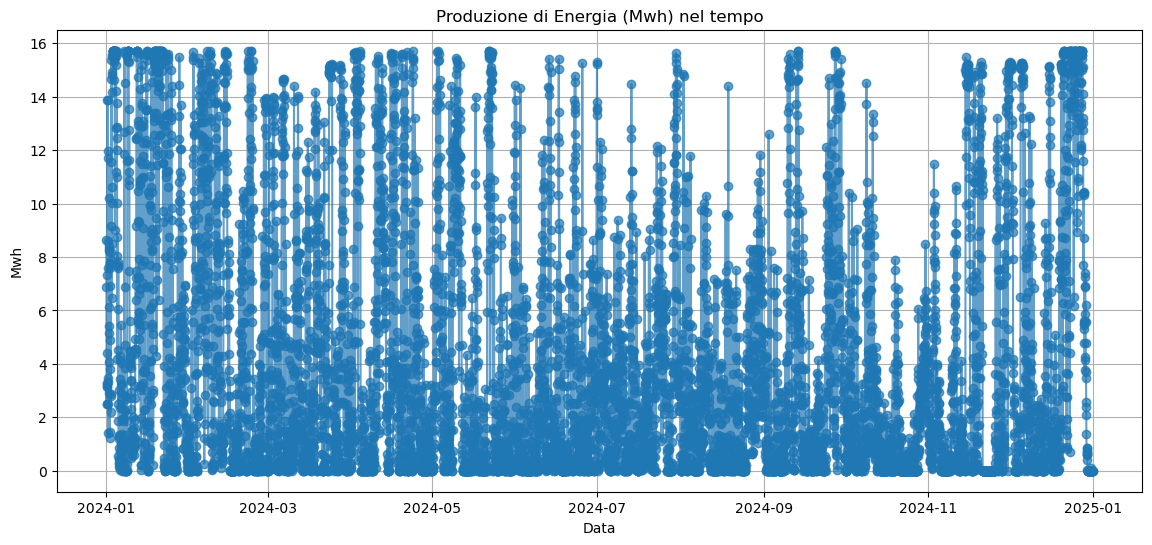

C:\Users\feder\AppData\Local\Temp\ipykernel_21004\3512516132.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mean = time_series["Mwh"].resample("M").mean()


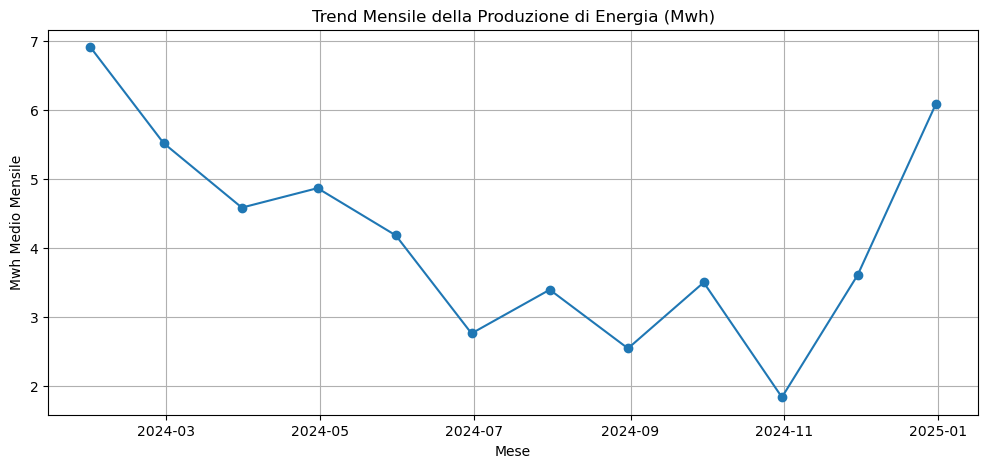

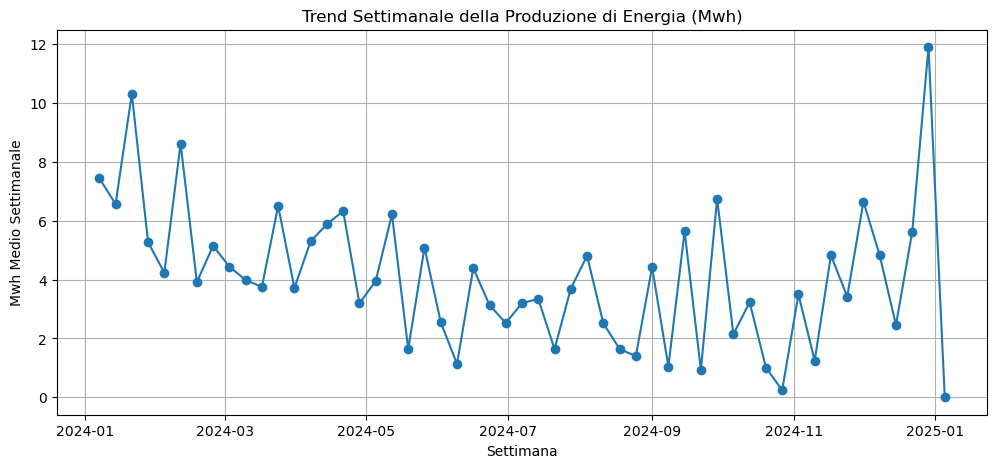

In [9]:
import matplotlib.pyplot as plt

# 1) Serie temporale target
time_series = df_merged_full[["Dataora", "Mwh"]].set_index("Dataora")

# 2) Plot andamento
plt.figure(figsize=(14,6))
plt.plot(time_series.index, time_series["Mwh"], marker='o', linestyle='-', alpha=0.7)
plt.title("Produzione di Energia (Mwh) nel tempo")
plt.xlabel("Data")
plt.ylabel("Mwh")
plt.grid(True)
plt.show()

# 3) Trend mensile (opzionale)
monthly_mean = time_series["Mwh"].resample("M").mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_mean.index, monthly_mean, marker='o', linestyle='-')
plt.title("Trend Mensile della Produzione di Energia (Mwh)")
plt.xlabel("Mese")
plt.ylabel("Mwh Medio Mensile")
plt.grid(True)
plt.show()

# 4) Eventuali aggregazioni ulteriori (settimanali, giornaliere)
weekly_mean = time_series["Mwh"].resample("W").mean()
plt.figure(figsize=(12,5))
plt.plot(weekly_mean.index, weekly_mean, marker='o', linestyle='-')
plt.title("Trend Settimanale della Produzione di Energia (Mwh)")
plt.xlabel("Settimana")
plt.ylabel("Mwh Medio Settimanale")
plt.grid(True)
plt.show()
